In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os

for root, dirs, files in os.walk('/content/drive/MyDrive'):
    for file in files:
        if file.endswith('.zip'):
            print(os.path.join(root, file))

/content/drive/MyDrive/ML_PROJECT_full.zip


In [ ]:
import os

for root, dirs, files in os.walk('/content/ML_PROJECT'):
    for file in files:
        print(os.path.join(root, file))

In [ ]:
import zipfile
import os

zip_path = "/content/drive/MyDrive/ML_PROJECT_full.zip"
extract_path = "/content/ML_PROJECT"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Extracted successfully!")

Extracted successfully!


In [ ]:
import os

for root, dirs, files in os.walk("/content/ML_PROJECT"):
    for file in files:
        print(os.path.join(root, file))

/content/ML_PROJECT/gnn_models.py
/content/ML_PROJECT/requirements.txt
/content/ML_PROJECT/app.py
/content/ML_PROJECT/run.py
/content/ML_PROJECT/aml_generator.py
/content/ML_PROJECT/SAML-D.csv
/content/ML_PROJECT/engine.py
/content/ML_PROJECT/test_aml_gnn.py
/content/ML_PROJECT/static/js/app.js
/content/ML_PROJECT/static/css/style.css
/content/ML_PROJECT/uploads/current_upload.csv
/content/ML_PROJECT/templates/index.html


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

all_figures = []

print("Libraries imported successfully.")

Libraries imported successfully.


In [ ]:
import zipfile
import os

zip_path = "/content/drive/MyDrive/ML_PROJECT_full.zip"
extract_path = "/content/ML_PROJECT"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    print("Files inside ZIP:")
    print(zip_ref.namelist())

    zip_ref.extractall(extract_path)

print("Dataset extracted successfully.")

Files inside ZIP:
['aml_generator.py', 'app.py', 'engine.py', 'gnn_models.py', 'requirements.txt', 'run.py', 'SAML-D.csv', 'test_aml_gnn.py', 'static/css/style.css', 'static/js/app.js', 'templates/index.html', 'uploads/current_upload.csv']
Dataset extracted successfully.


In [ ]:
import os

csv_path = None

for root, dirs, files in os.walk("/content/ML_PROJECT"):
    for file in files:
        if file.lower() == "saml-d.csv":
            csv_path = os.path.join(root, file)

print("CSV path:", csv_path)

CSV path: /content/ML_PROJECT/SAML-D.csv


In [ ]:
# Load a representative sample for EDA
df = pd.read_csv(
    csv_path,
    nrows=200000
)

print("Dataset loaded successfully.")
print("Shape:", df.shape)

display(df.head())

Dataset loaded successfully.
Shape: (200000, 12)


,Time,Date,Sender_account,Receiver_account,Amount,Payment_currency,Received_currency,Sender_bank_location,Receiver_bank_location,Payment_type,Is_laundering,Laundering_type
0,10:35:19,2022-10-07,8724731955,2769355426,1459.15,UK pounds,UK pounds,UK,UK,Cash Deposit,0,Normal_Cash_Deposits
1,10:35:20,2022-10-07,1491989064,8401255335,6019.64,UK pounds,Dirham,UK,UAE,Cross-border,0,Normal_Fan_Out
2,10:35:20,2022-10-07,287305149,4404767002,14328.44,UK pounds,UK pounds,UK,UK,Cheque,0,Normal_Small_Fan_Out
3,10:35:21,2022-10-07,5376652437,9600420220,11895.00,UK pounds,UK pounds,UK,UK,ACH,0,Normal_Fan_In
4,10:35:21,2022-10-07,9614186178,3803336972,115.25,UK pounds,UK pounds,UK,UK,Cash Deposit,0,Normal_Cash_Deposits


In [ ]:
print("Dataset Information:")
print()

print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nDataset Information:")
df.info()

Dataset Information:

Number of Rows: 200000
Number of Columns: 12

Column Names:
['Time', 'Date', 'Sender_account', 'Receiver_account', 'Amount', 'Payment_currency', 'Received_currency', 'Sender_bank_location', 'Receiver_bank_location', 'Payment_type', 'Is_laundering', 'Laundering_type']

Data Types:
Time                       object
Date                       object
Sender_account              int64
Receiver_account            int64
Amount                    float64
Payment_currency           object
Received_currency          object
Sender_bank_location       object
Receiver_bank_location     object
Payment_type               object
Is_laundering               int64
Laundering_type            object
dtype: object

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 12 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   Time                    20000

In [ ]:
numerical_features = df.select_dtypes(
    include=['int64', 'float64']
).columns.tolist()

print("Numerical Features:")
print(numerical_features)

Numerical Features:
['Sender_account', 'Receiver_account', 'Amount', 'Is_laundering']


In [ ]:
categorical_features = df.select_dtypes(
    include=['object', 'category', 'bool']
).columns.tolist()

print("Categorical Features:")
print(categorical_features)

Categorical Features:
['Time', 'Date', 'Payment_currency', 'Received_currency', 'Sender_bank_location', 'Receiver_bank_location', 'Payment_type', 'Laundering_type']


In [ ]:
print("Number of Unique Values in Each Column:\n")

for col in df.columns:
    print(f"{col}: {df[col].nunique()} unique values")

Number of Unique Values in Each Column:

Time: 70057 unique values
Date: 8 unique values
Sender_account: 30882 unique values
Receiver_account: 85792 unique values
Amount: 185970 unique values
Payment_currency: 13 unique values
Received_currency: 13 unique values
Sender_bank_location: 18 unique values
Receiver_bank_location: 18 unique values
Payment_type: 7 unique values
Is_laundering: 2 unique values
Laundering_type: 27 unique values


In [ ]:
print("Statistical Summary of Numerical Features:")

display(df[numerical_features].describe())

Statistical Summary of Numerical Features:


,Sender_account,Receiver_account,Amount,Is_laundering
count,2.000000e+05,2.000000e+05,2.000000e+05,200000.000000
mean,4.987479e+09,5.088063e+09,8.725546e+03,0.001180
std,2.869313e+09,2.824707e+09,2.717268e+04,0.034331
min,9.217200e+04,4.823800e+04,8.830000e+00,0.000000
25%,2.553229e+09,2.670254e+09,2.114117e+03,0.000000
50%,4.927156e+09,5.145155e+09,6.131880e+03,0.000000
75%,7.452462e+09,7.507210e+09,1.043470e+04,0.000000
max,9.999706e+09,9.999971e+09,6.213932e+06,1.000000


In [ ]:
print("Missing Values:\n")

missing_values = df.isnull().sum()

print(missing_values)

Missing Values:

Time                      0
Date                      0
Sender_account            0
Receiver_account          0
Amount                    0
Payment_currency          0
Received_currency         0
Sender_bank_location      0
Receiver_bank_location    0
Payment_type              0
Is_laundering             0
Laundering_type           0
dtype: int64


In [ ]:
missing_percentage = (
    df.isnull().sum() / len(df) * 100
).sort_values(ascending=False)

missing_table = pd.DataFrame({
    'Missing Values': df.isnull().sum(),
    'Missing Percentage': missing_percentage
})

display(missing_table)

,Missing Values,Missing Percentage
Time,0,0.0
Date,0,0.0
Sender_account,0,0.0
Receiver_account,0,0.0
Amount,0,0.0
Payment_currency,0,0.0
Received_currency,0,0.0
Sender_bank_location,0,0.0
Receiver_bank_location,0,0.0
Payment_type,0,0.0


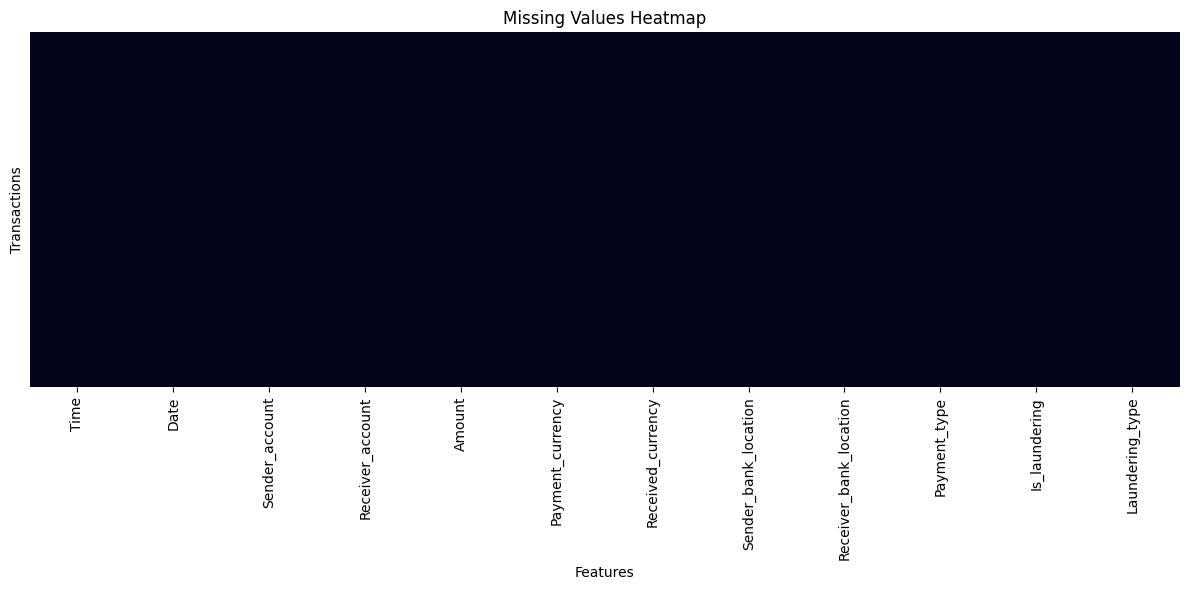

In [ ]:
fig = plt.figure(figsize=(12, 6))

sns.heatmap(
    df.isnull(),
    cbar=False,
    yticklabels=False
)

plt.title("Missing Values Heatmap")
plt.xlabel("Features")
plt.ylabel("Transactions")
plt.tight_layout()
plt.show()

all_figures.append(fig)

In [ ]:
duplicate_count = df.duplicated().sum()

print("Number of Duplicate Rows:", duplicate_count)

Number of Duplicate Rows: 0


In [ ]:
print("Distribution of Is_laundering:")

print(df['Is_laundering'].value_counts())

print("\nPercentage Distribution:")

print(
    df['Is_laundering']
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Distribution of Is_laundering:
Is_laundering
0    199764
1       236
Name: count, dtype: int64

Percentage Distribution:
Is_laundering
0    99.88
1     0.12
Name: proportion, dtype: float64


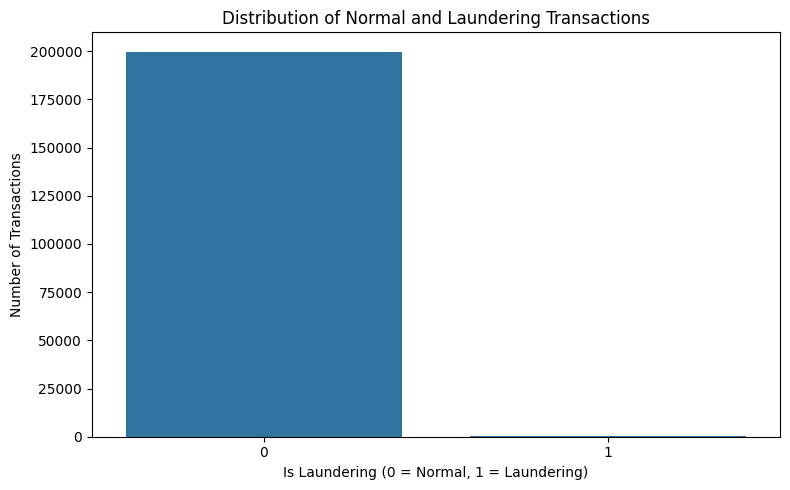

In [ ]:
fig = plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x='Is_laundering'
)

plt.title("Distribution of Normal and Laundering Transactions")
plt.xlabel("Is Laundering (0 = Normal, 1 = Laundering)")
plt.ylabel("Number of Transactions")

plt.tight_layout()
plt.show()

all_figures.append(fig)

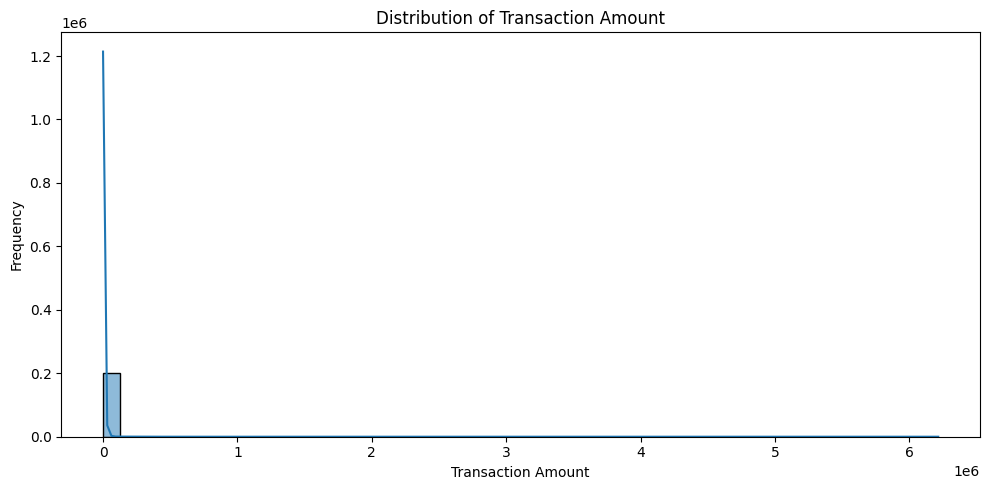

In [ ]:
fig = plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x='Amount',
    bins=50,
    kde=True
)

plt.title("Distribution of Transaction Amount")
plt.xlabel("Transaction Amount")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

all_figures.append(fig)

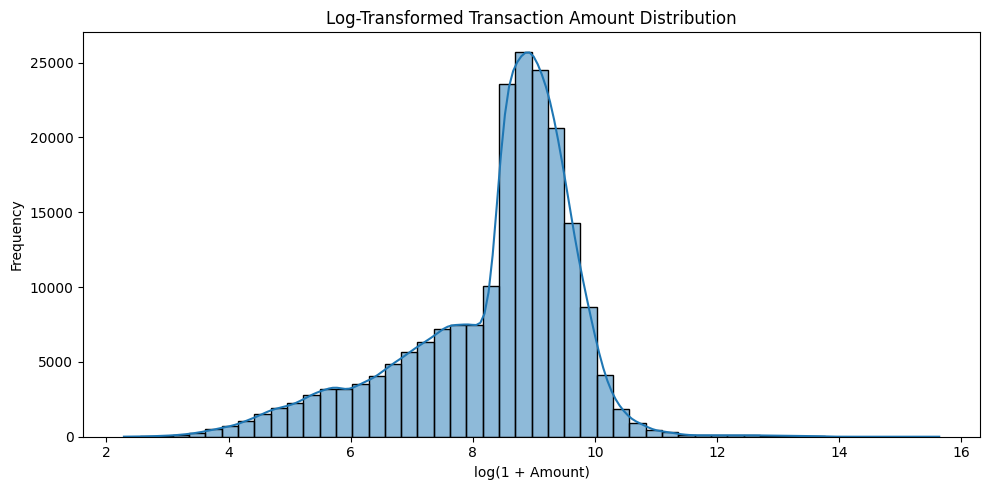

In [ ]:
fig = plt.figure(figsize=(10, 5))

sns.histplot(
    np.log1p(df['Amount']),
    bins=50,
    kde=True
)

plt.title("Log-Transformed Transaction Amount Distribution")
plt.xlabel("log(1 + Amount)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

all_figures.append(fig)

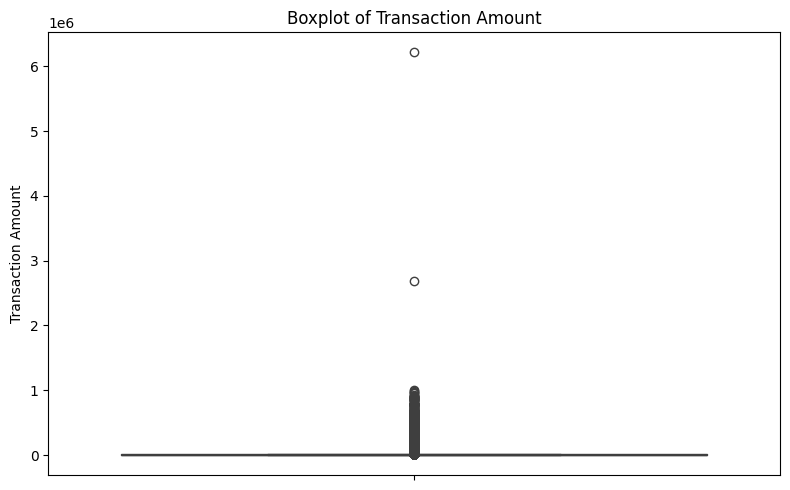

In [ ]:
fig = plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    y='Amount'
)

plt.title("Boxplot of Transaction Amount")
plt.ylabel("Transaction Amount")

plt.tight_layout()
plt.show()

all_figures.append(fig)

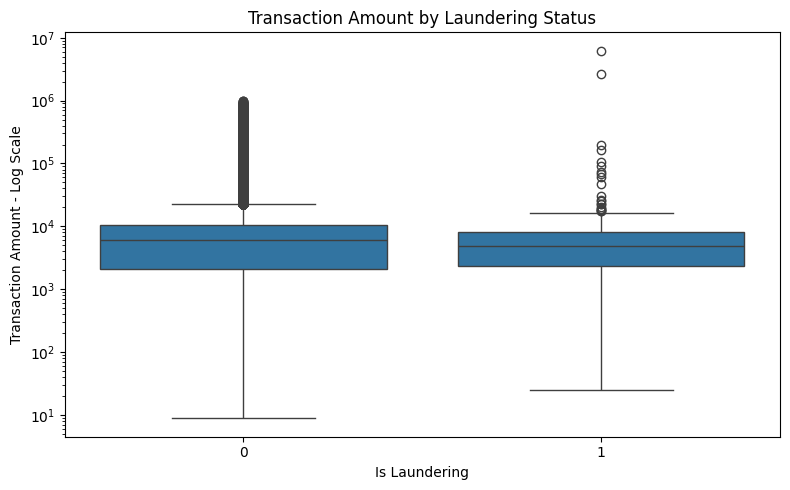

In [ ]:
fig = plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x='Is_laundering',
    y='Amount'
)

plt.yscale('log')

plt.title("Transaction Amount by Laundering Status")
plt.xlabel("Is Laundering")
plt.ylabel("Transaction Amount - Log Scale")

plt.tight_layout()
plt.show()

all_figures.append(fig)

In [ ]:
fig = plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x='Is_laundering',
    y='Amount'
)

plt.yscale('log')

plt.title("Transaction Amount by Laundering Status")
plt.xlabel("Is Laundering")
plt.ylabel("Transaction Amount - Log Scale")

plt.tight_layout()
plt.show()

all_figures.append(fig)

KeyboardInterrupt: 

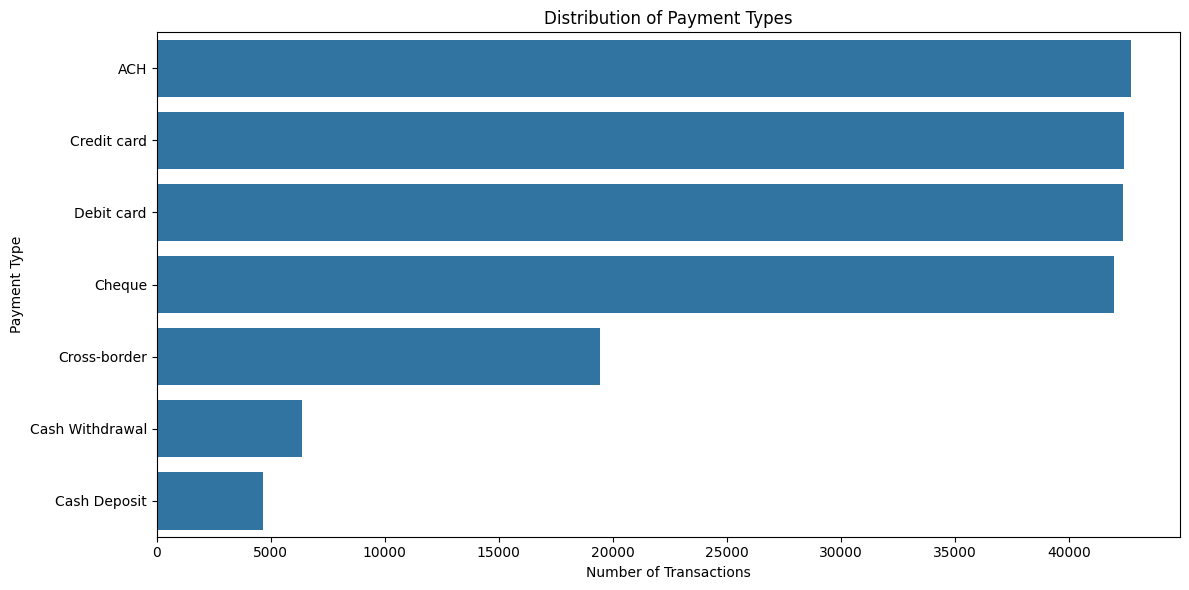

In [ ]:
fig = plt.figure(figsize=(12, 6))

sns.countplot(
    data=df,
    y='Payment_type',
    order=df['Payment_type'].value_counts().index
)

plt.title("Distribution of Payment Types")
plt.xlabel("Number of Transactions")
plt.ylabel("Payment Type")

plt.tight_layout()
plt.show()

all_figures.append(fig)

Is_laundering,0,1
Payment_type,,
ACH,42704,28
Cash Deposit,4653,28
Cash Withdrawal,6346,33
Cheque,41936,24
Credit card,42399,30
Cross-border,19381,65
Debit card,42345,28


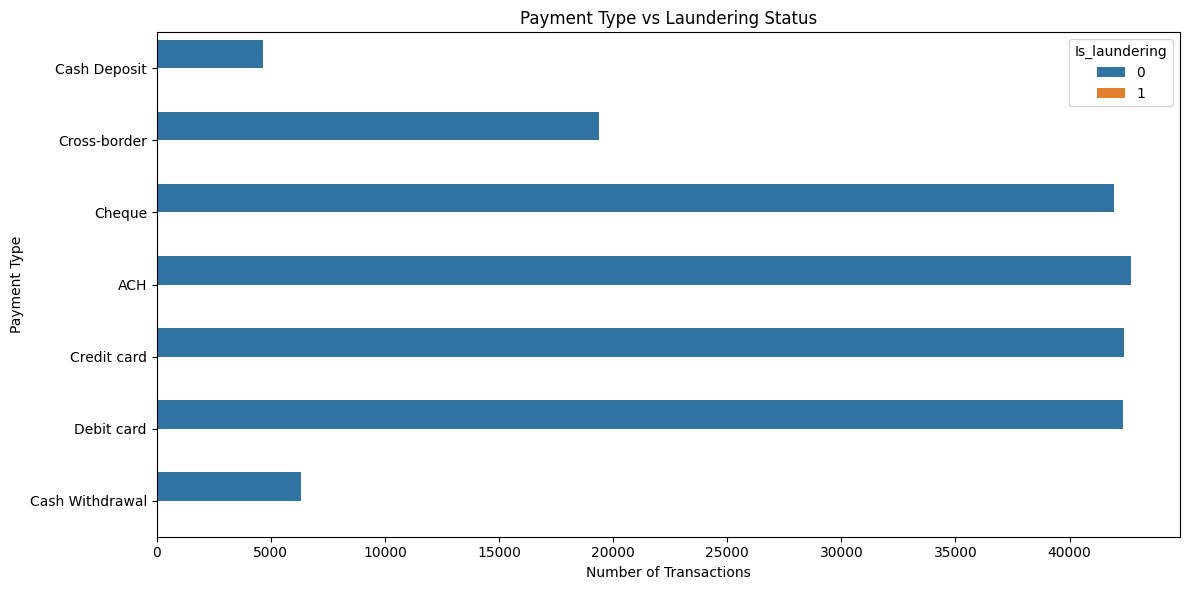

In [ ]:
payment_laundering = pd.crosstab(
    df['Payment_type'],
    df['Is_laundering']
)

display(payment_laundering)

fig = plt.figure(figsize=(12, 6))

sns.countplot(
    data=df,
    y='Payment_type',
    hue='Is_laundering'
)

plt.title("Payment Type vs Laundering Status")
plt.xlabel("Number of Transactions")
plt.ylabel("Payment Type")

plt.tight_layout()
plt.show()

all_figures.append(fig)

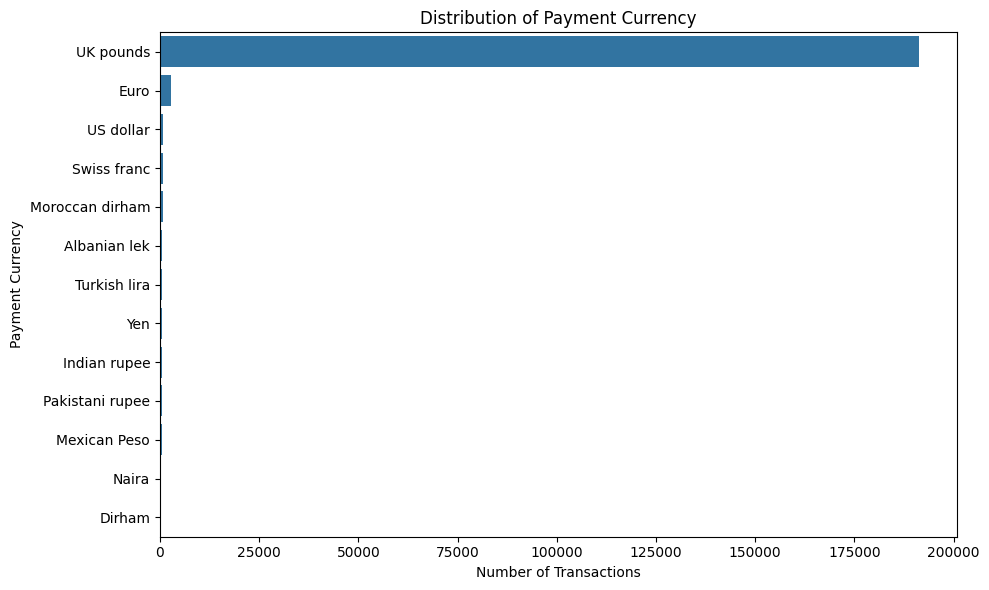

In [ ]:
fig = plt.figure(figsize=(10, 6))

sns.countplot(
    data=df,
    y='Payment_currency',
    order=df['Payment_currency'].value_counts().index
)

plt.title("Distribution of Payment Currency")
plt.xlabel("Number of Transactions")
plt.ylabel("Payment Currency")

plt.tight_layout()
plt.show()

all_figures.append(fig)

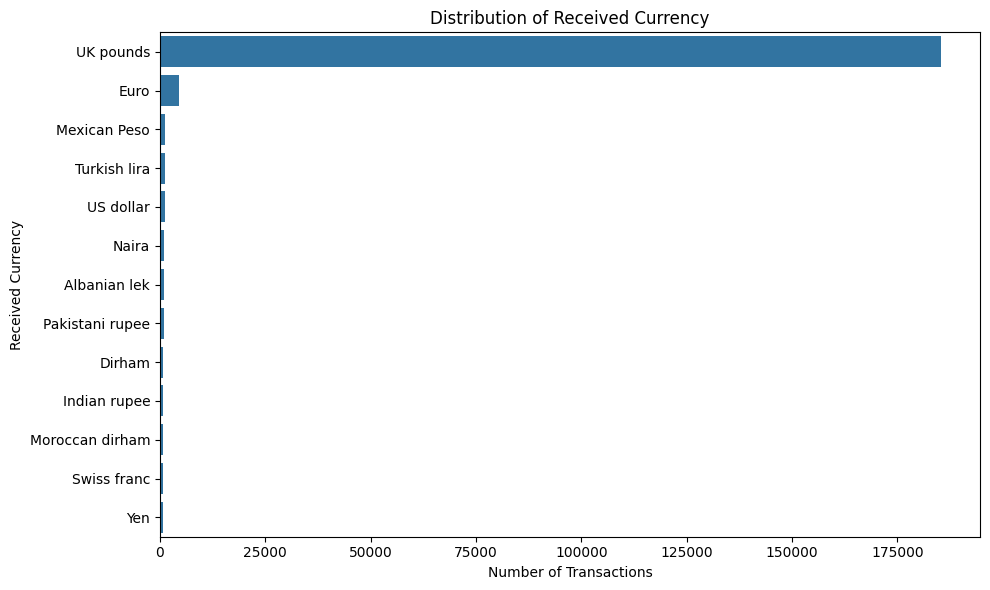

In [ ]:
fig = plt.figure(figsize=(10, 6))

sns.countplot(
    data=df,
    y='Received_currency',
    order=df['Received_currency'].value_counts().index
)

plt.title("Distribution of Received Currency")
plt.xlabel("Number of Transactions")
plt.ylabel("Received Currency")

plt.tight_layout()
plt.show()

all_figures.append(fig)

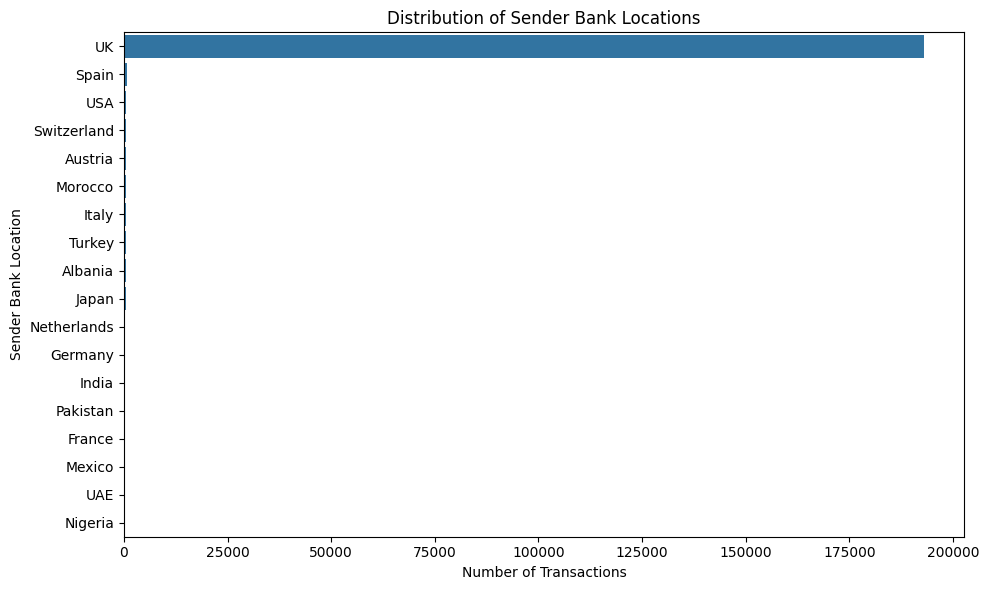

In [ ]:
fig = plt.figure(figsize=(10, 6))

sns.countplot(
    data=df,
    y='Sender_bank_location',
    order=df['Sender_bank_location'].value_counts().index
)

plt.title("Distribution of Sender Bank Locations")
plt.xlabel("Number of Transactions")
plt.ylabel("Sender Bank Location")

plt.tight_layout()
plt.show()

all_figures.append(fig)

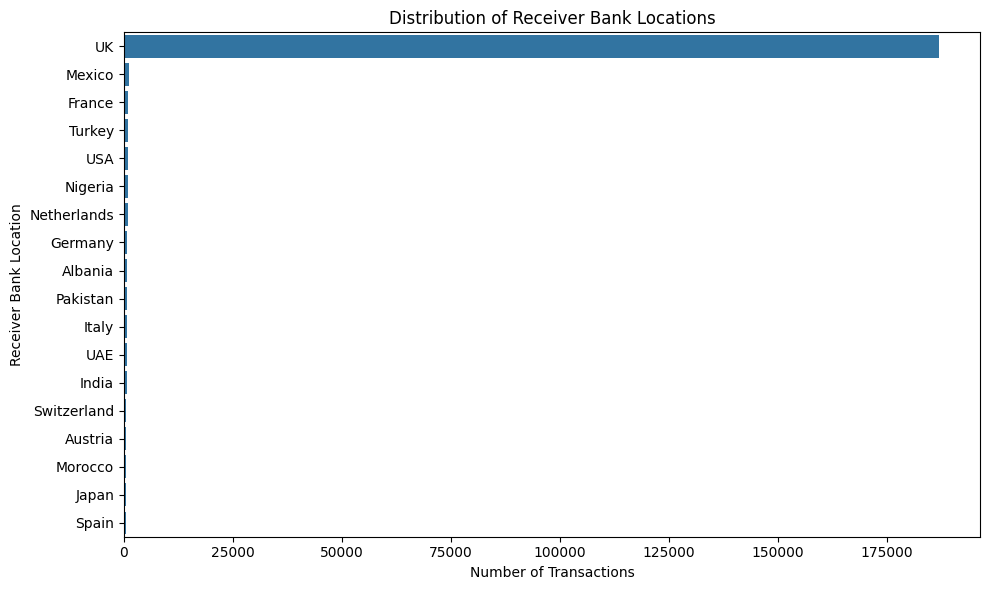

In [ ]:
fig = plt.figure(figsize=(10, 6))

sns.countplot(
    data=df,
    y='Receiver_bank_location',
    order=df['Receiver_bank_location'].value_counts().index
)

plt.title("Distribution of Receiver Bank Locations")
plt.xlabel("Number of Transactions")
plt.ylabel("Receiver Bank Location")

plt.tight_layout()
plt.show()

all_figures.append(fig)

In [ ]:
print("Laundering Type Distribution:")

display(
    df['Laundering_type']
    .value_counts()
    .to_frame('Count')
)

Laundering Type Distribution:


,Count
Laundering_type,
Normal_Small_Fan_Out,73760
Normal_Fan_Out,48062
Normal_Fan_In,47128
Normal_Group,11207
Normal_Cash_Withdrawal,6486
Normal_Cash_Deposits,4653
Normal_Periodical,4187
Normal_Mutual,1952
Normal_Plus_Mutual,1010


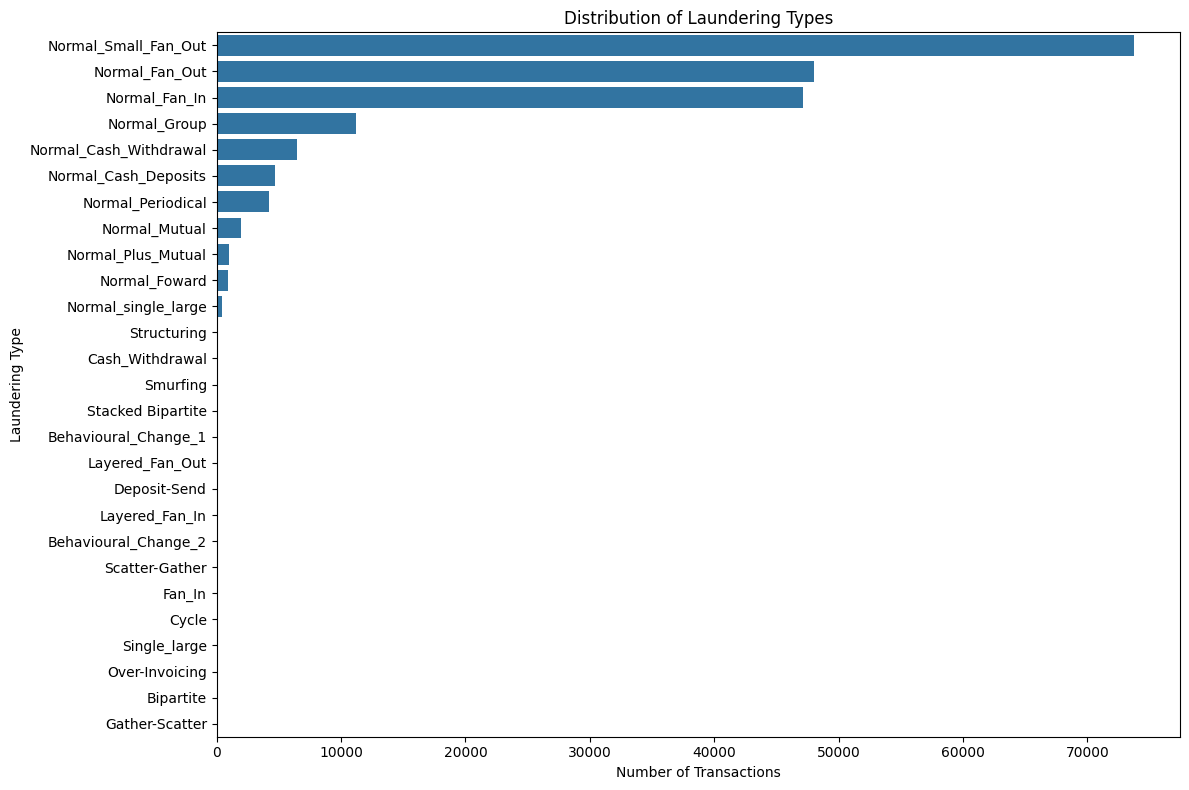

In [ ]:
fig = plt.figure(figsize=(12, 8))

laundering_counts = (
    df['Laundering_type']
    .value_counts()
)

sns.barplot(
    x=laundering_counts.values,
    y=laundering_counts.index
)

plt.title("Distribution of Laundering Types")
plt.xlabel("Number of Transactions")
plt.ylabel("Laundering Type")

plt.tight_layout()
plt.show()

all_figures.append(fig)

In [ ]:
df['Date'] = pd.to_datetime(
    df['Date'],
    errors='coerce'
)

print("Date Range:")

print("Minimum Date:", df['Date'].min())
print("Maximum Date:", df['Date'].max())

Date Range:
Minimum Date: 2022-10-07 00:00:00
Maximum Date: 2022-10-14 00:00:00


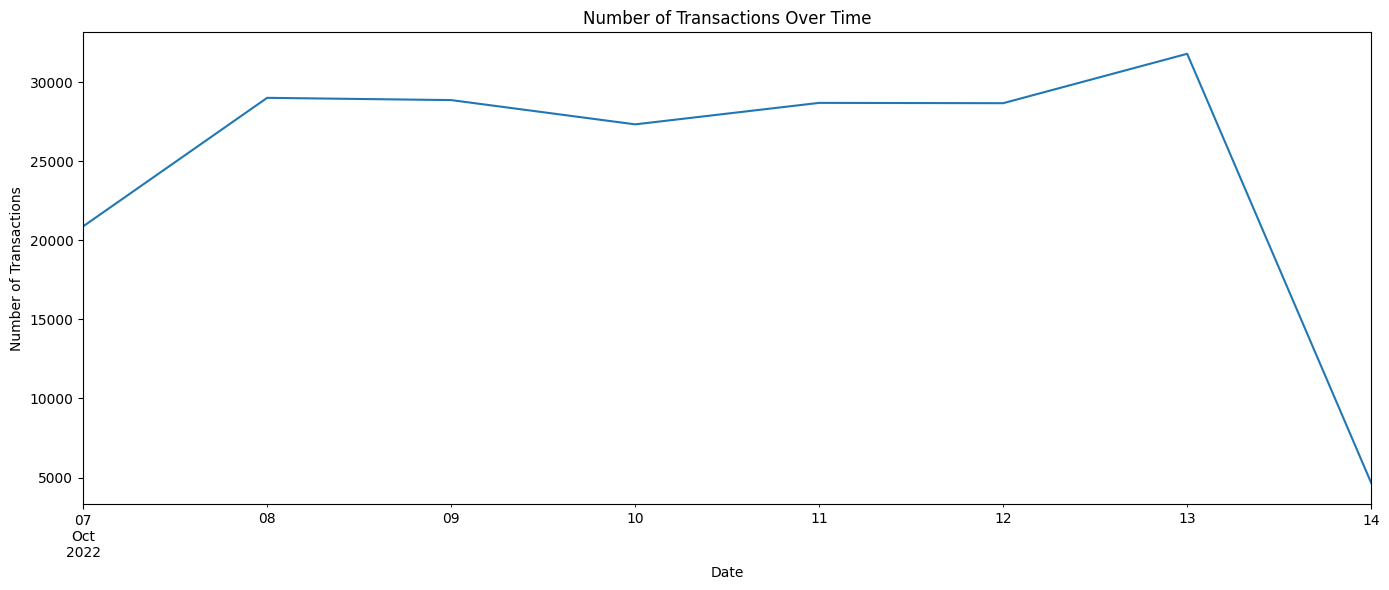

In [ ]:
daily_transactions = (
    df.groupby('Date')
    .size()
)

fig = plt.figure(figsize=(14, 6))

daily_transactions.plot()

plt.title("Number of Transactions Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Transactions")

plt.tight_layout()
plt.show()

all_figures.append(fig)

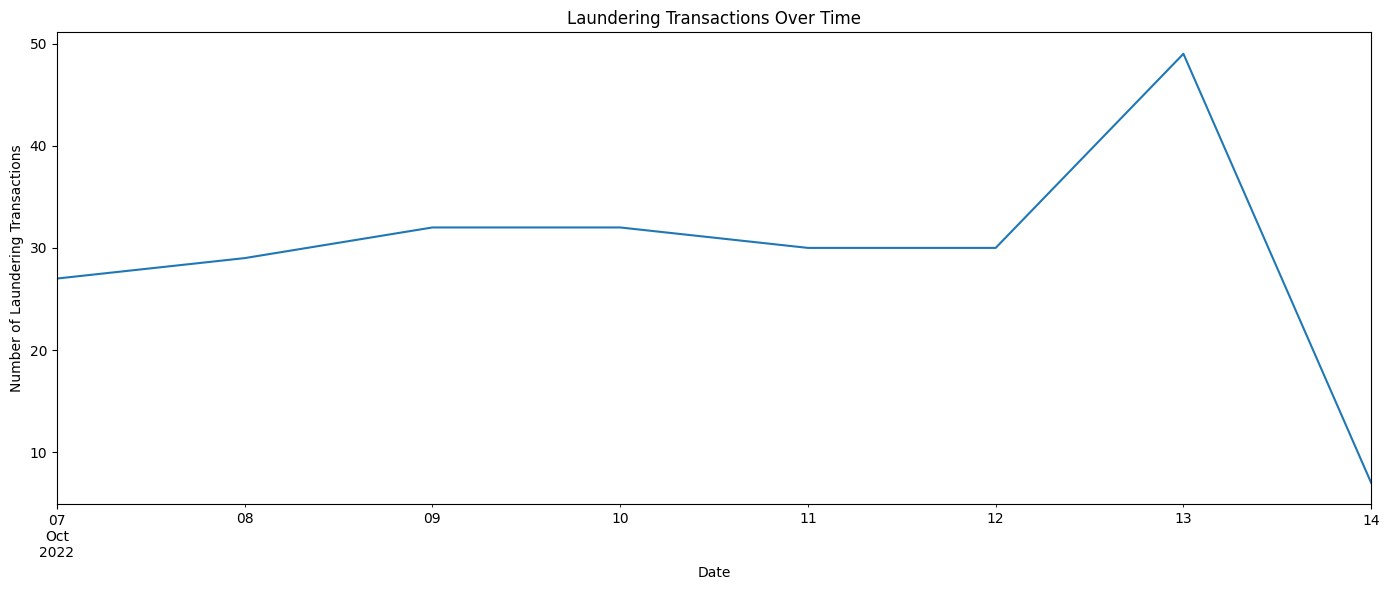

In [ ]:
daily_laundering = (
    df.groupby('Date')['Is_laundering']
    .sum()
)

fig = plt.figure(figsize=(14, 6))

daily_laundering.plot()

plt.title("Laundering Transactions Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Laundering Transactions")

plt.tight_layout()
plt.show()

all_figures.append(fig)

In [ ]:
df['Time'] = pd.to_datetime(
    df['Time'],
    format='%H:%M:%S',
    errors='coerce'
)

df['Hour'] = df['Time'].dt.hour

hourly_transactions = df['Hour'].value_counts().sort_index()

display(hourly_transactions)

,count
Hour,
0,2580
1,2550
2,2574
3,2685
4,2604
5,2609
6,2476
7,3138
8,11519


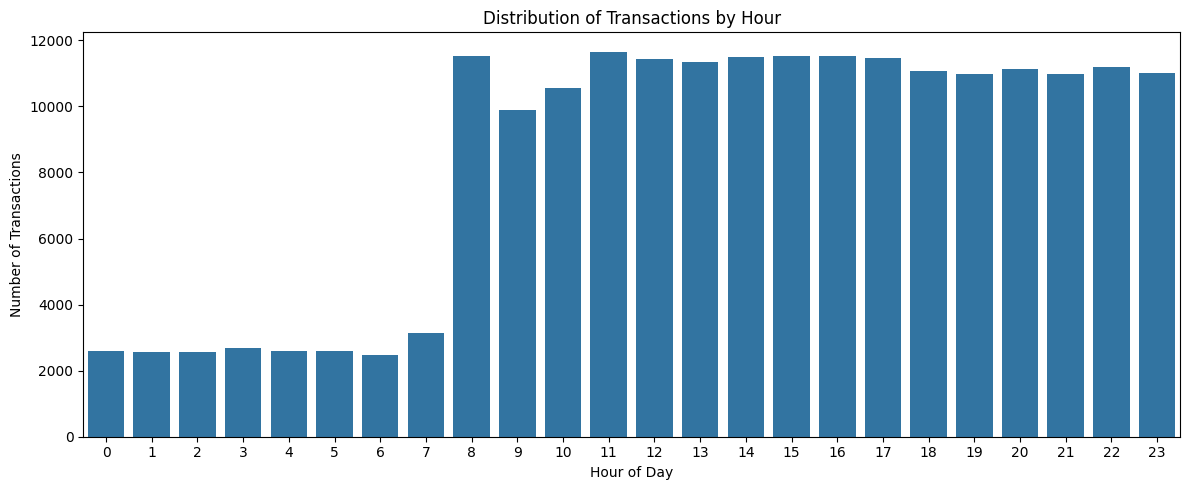

In [ ]:
fig = plt.figure(figsize=(12, 5))

sns.countplot(
    data=df,
    x='Hour'
)

plt.title("Distribution of Transactions by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Transactions")

plt.tight_layout()
plt.show()

all_figures.append(fig)

In [ ]:
payment_analysis = (
    df.groupby('Payment_type')['Is_laundering']
    .agg(['count', 'sum', 'mean'])
)

payment_analysis['laundering_percentage'] = (
    payment_analysis['mean'] * 100
)

payment_analysis = payment_analysis.sort_values(
    'laundering_percentage',
    ascending=False
)

display(payment_analysis)

,count,sum,mean,laundering_percentage
Payment_type,,,,
Cash Deposit,4681,28,0.005982,0.598163
Cash Withdrawal,6379,33,0.005173,0.517322
Cross-border,19446,65,0.003343,0.334259
Credit card,42429,30,0.000707,0.070706
Debit card,42373,28,0.000661,0.066080
ACH,42732,28,0.000655,0.065525
Cheque,41960,24,0.000572,0.057197


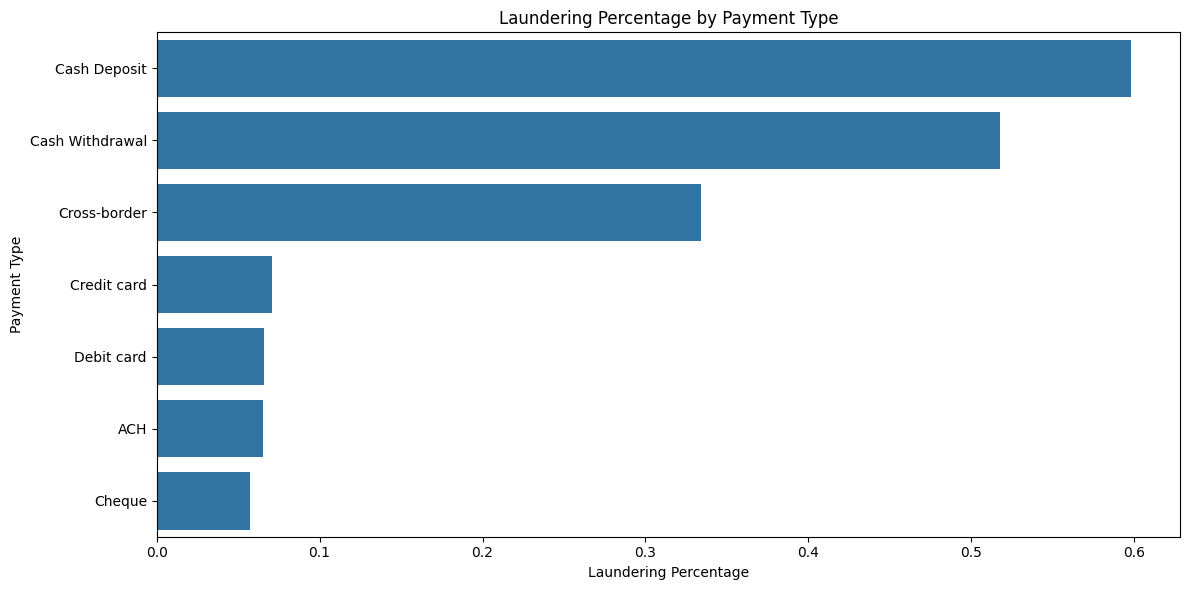

In [ ]:
fig = plt.figure(figsize=(12, 6))

sns.barplot(
    data=payment_analysis.reset_index(),
    x='laundering_percentage',
    y='Payment_type'
)

plt.title("Laundering Percentage by Payment Type")
plt.xlabel("Laundering Percentage")
plt.ylabel("Payment Type")

plt.tight_layout()
plt.show()

all_figures.append(fig)

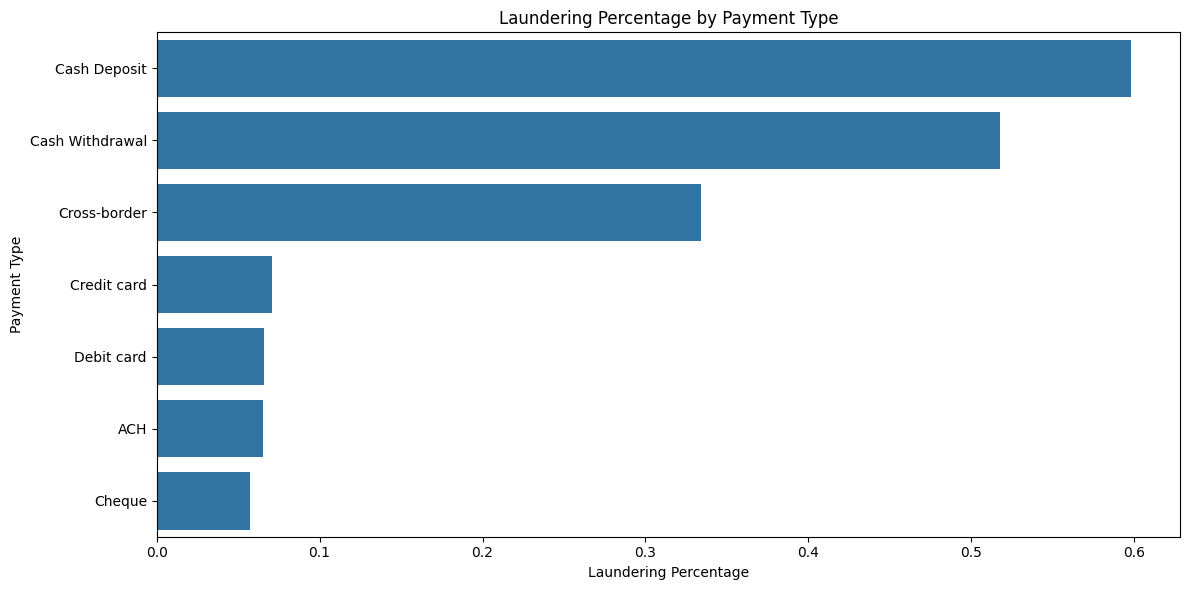

In [ ]:
fig = plt.figure(figsize=(12, 6))

sns.barplot(
    data=payment_analysis.reset_index(),
    x='laundering_percentage',
    y='Payment_type'
)

plt.title("Laundering Percentage by Payment Type")
plt.xlabel("Laundering Percentage")
plt.ylabel("Payment Type")

plt.tight_layout()
plt.show()

all_figures.append(fig)

In [ ]:
corr_matrix = df[numerical_features].corr()

print("Correlation Matrix:")

display(corr_matrix)

Correlation Matrix:


,Sender_account,Receiver_account,Amount,Is_laundering
Sender_account,1.000000,-0.003381,-0.001287,0.003372
Receiver_account,-0.003381,1.000000,-0.001294,-0.005014
Amount,-0.001287,-0.001294,1.000000,0.048083
Is_laundering,0.003372,-0.005014,0.048083,1.000000


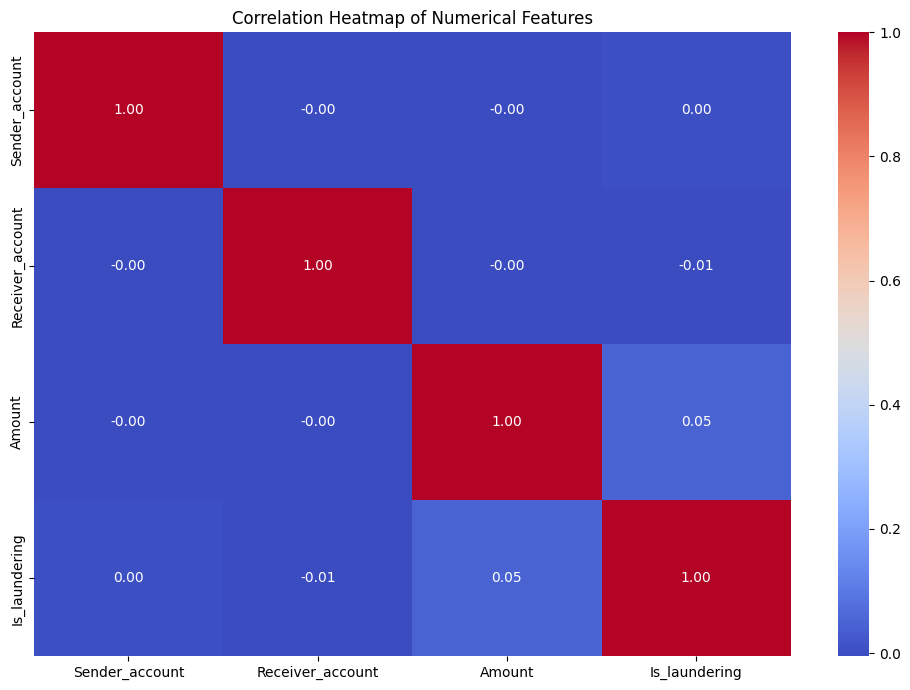

In [ ]:
fig = plt.figure(figsize=(10, 7))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Heatmap of Numerical Features")

plt.tight_layout()
plt.show()

all_figures.append(fig)

In [ ]:
if 'Is_laundering' in corr_matrix.columns:

    laundering_corr = (
        corr_matrix['Is_laundering']
        .sort_values(ascending=False)
    )

    print("Correlation of Numerical Features with Is_laundering:")
    print(laundering_corr)

else:
    print("Is_laundering column not found.")

Correlation of Numerical Features with Is_laundering:
Is_laundering       1.000000
Amount              0.048083
Sender_account      0.003372
Receiver_account   -0.005014
Name: Is_laundering, dtype: float64


In [ ]:
print(
    "Unique Sender Accounts:",
    df['Sender_account'].nunique()
)

print(
    "Unique Receiver Accounts:",
    df['Receiver_account'].nunique()
)

print(
    "Unique Sender-Receiver Pairs:",
    df[['Sender_account', 'Receiver_account']]
    .drop_duplicates()
    .shape[0]
)

Unique Sender Accounts: 30882
Unique Receiver Accounts: 85792
Unique Sender-Receiver Pairs: 93595


In [ ]:
top_senders = (
    df['Sender_account']
    .value_counts()
    .head(20)
)

display(
    top_senders.to_frame('Transaction_Count')
)

,Transaction_Count
Sender_account,
8278374434,273
382301928,268
8976725341,266
6984051591,266
7707725699,266
1452170043,266
3649354016,265
15297964,265
1440303656,264


In [ ]:
top_receivers = (
    df['Receiver_account']
    .value_counts()
    .head(20)
)

display(
    top_receivers.to_frame('Transaction_Count')
)

,Transaction_Count
Receiver_account,
6086421020,243
6130835432,242
1491736788,242
2670254274,241
3776724367,241
3454889,241
9683990807,241
7543159220,241
5692049884,240


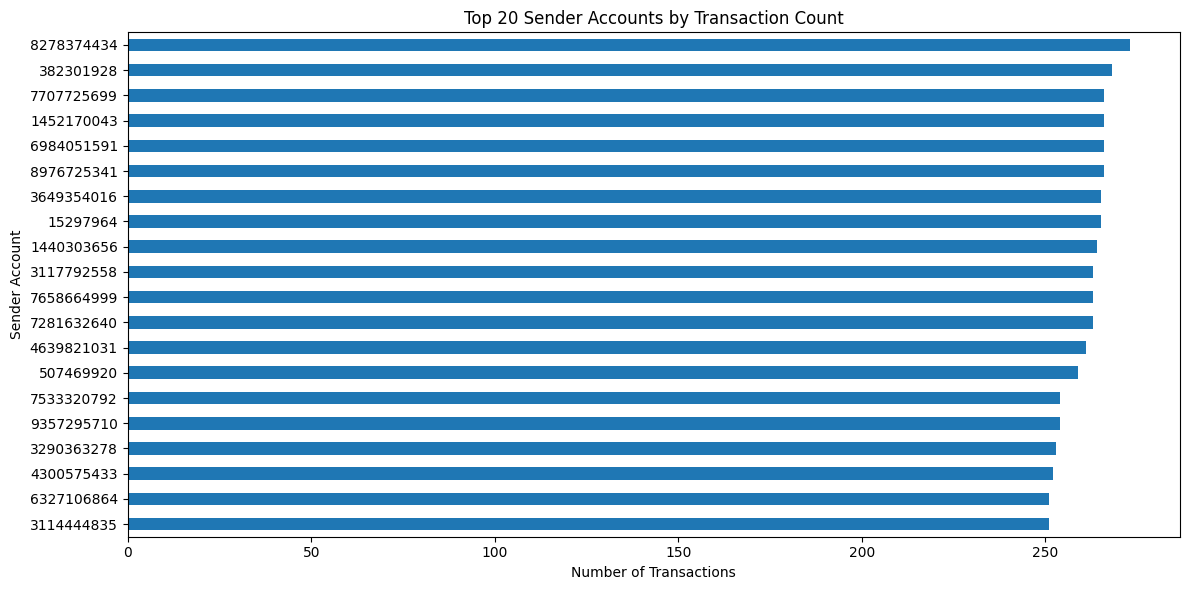

In [ ]:
fig = plt.figure(figsize=(12, 6))

top_senders.sort_values().plot(
    kind='barh'
)

plt.title("Top 20 Sender Accounts by Transaction Count")
plt.xlabel("Number of Transactions")
plt.ylabel("Sender Account")

plt.tight_layout()
plt.show()

all_figures.append(fig)

In [ ]:
amount_analysis = (
    df.groupby('Is_laundering')['Amount']
    .agg([
        'count',
        'mean',
        'median',
        'std',
        'min',
        'max'
    ])
)

display(amount_analysis)

,count,mean,median,std,min,max
Is_laundering,,,,,,
0,199764,8680.638376,6134.285,22584.650756,8.83,998453.63
1,236,46737.701012,4864.785,439711.514331,24.77,6213931.56


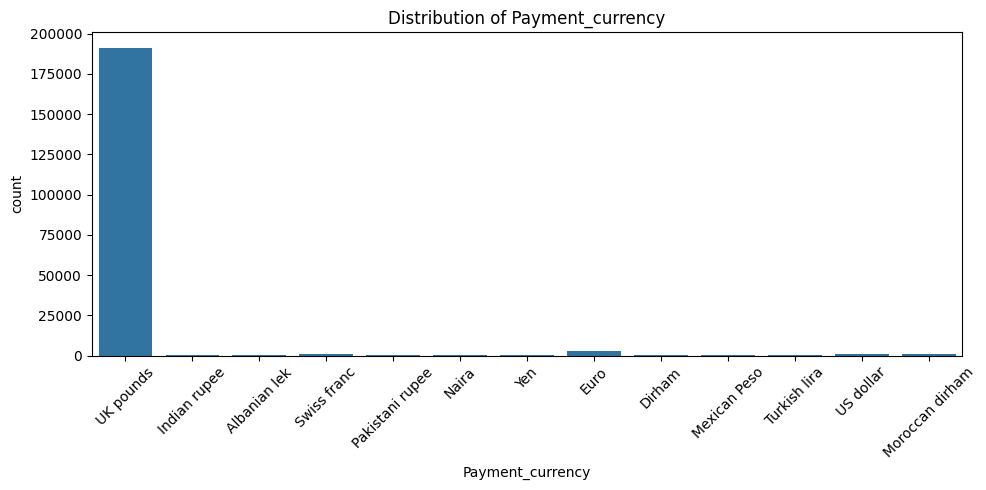

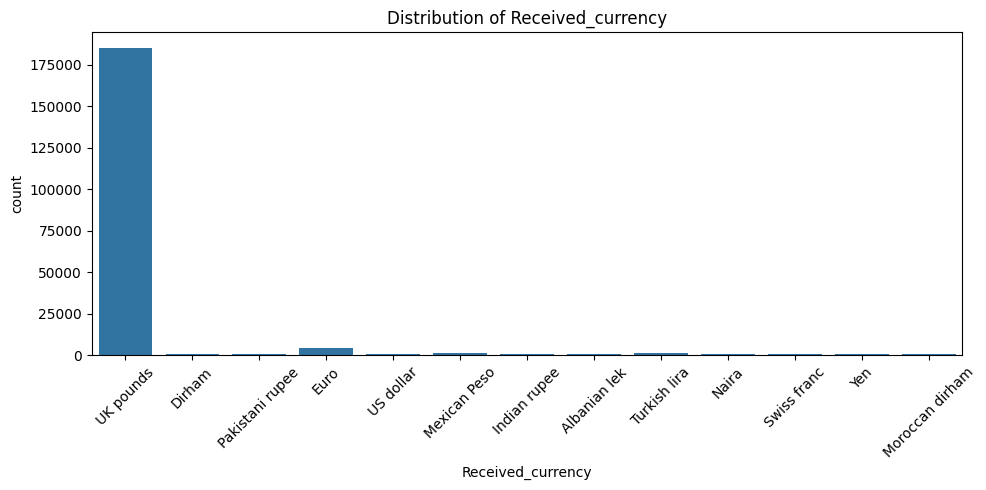

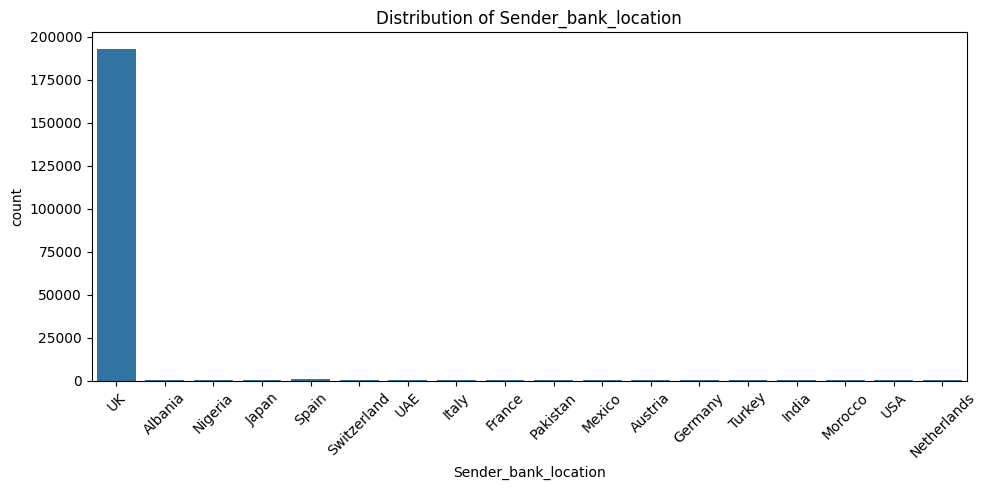

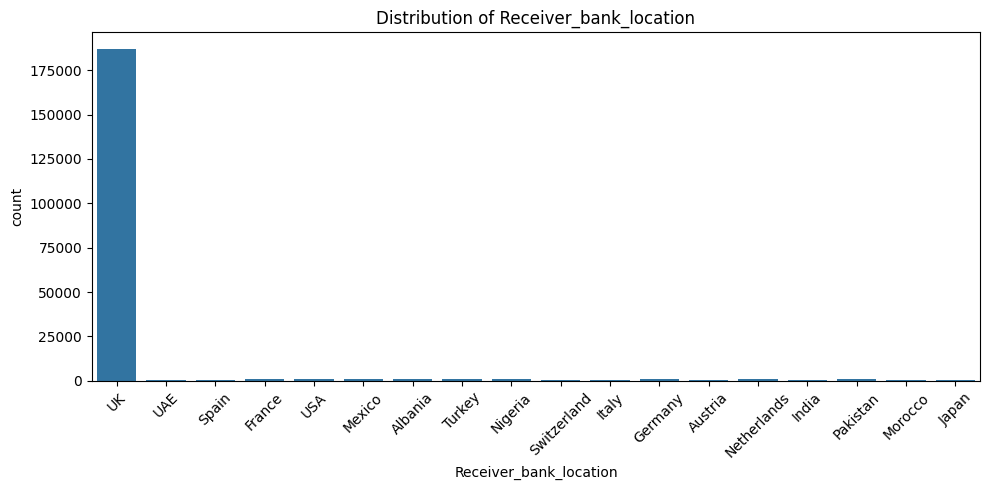

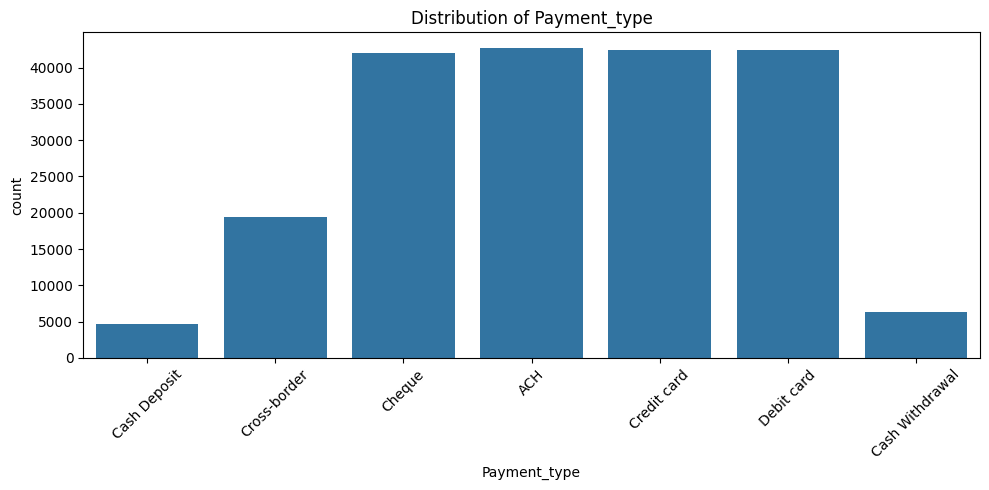

In [ ]:
categorical_cols = [
    'Payment_currency',
    'Received_currency',
    'Sender_bank_location',
    'Receiver_bank_location',
    'Payment_type'
]

for col in categorical_cols:

    if df[col].nunique() <= 20:

        fig = plt.figure(figsize=(10, 5))

        sns.countplot(
            data=df,
            x=col
        )

        plt.title(f'Distribution of {col}')
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

        all_figures.append(fig)

In [ ]:
print("========== AML EDA SUMMARY ==========")

print("Rows analyzed:", df.shape[0])
print("Columns:", df.shape[1])

print("\nColumns:")
print(df.columns.tolist())

print("\nUnique Sender Accounts:",
      df['Sender_account'].nunique())

print("Unique Receiver Accounts:",
      df['Receiver_account'].nunique())

print("Unique Payment Types:",
      df['Payment_type'].nunique())

print("Unique Payment Currencies:",
      df['Payment_currency'].nunique())

print("Unique Laundering Types:",
      df['Laundering_type'].nunique())

print(
    "\nNormal Transactions:",
    (df['Is_laundering'] == 0).sum()
)

print(
    "Laundering Transactions:",
    (df['Is_laundering'] == 1).sum()
)

print("======================================")

========== AML EDA SUMMARY ==========
Rows analyzed: 200000
Columns: 13

Columns:
['Time', 'Date', 'Sender_account', 'Receiver_account', 'Amount', 'Payment_currency', 'Received_currency', 'Sender_bank_location', 'Receiver_bank_location', 'Payment_type', 'Is_laundering', 'Laundering_type', 'Hour']

Unique Sender Accounts: 30882
Unique Receiver Accounts: 85792
Unique Payment Types: 7
Unique Payment Currencies: 13
Unique Laundering Types: 27

Normal Transactions: 199764
Laundering Transactions: 236


In [ ]:
from matplotlib.backends.backend_pdf import PdfPages
import os

pdf_path = "/content/AML_EDA_Report.pdf"

with PdfPages(pdf_path) as pdf:
    for i, fig in enumerate(all_figures):
        try:
            pdf.savefig(fig, bbox_inches="tight")
        except Exception as e:
            print(f"Could not save figure {i+1}: {e}")

print("EDA Report saved successfully!")
print("File location:", pdf_path)
print("File size:", round(os.path.getsize(pdf_path) / (1024 * 1024), 2), "MB")

EDA Report saved successfully!
File location: /content/AML_EDA_Report.pdf
File size: 24.56 MB


In [ ]:
print("""
EDA CONCLUSION

The SAML-D dataset contains transaction-level information
that can be used for Anti-Money Laundering detection.

The dataset includes:
- Sender and receiver accounts
- Transaction amount
- Payment and received currencies
- Sender and receiver bank locations
- Payment type
- Laundering indicator
- Laundering type
- Date and time information

The EDA analyzed:
- Dataset structure
- Numerical and categorical features
- Missing values
- Duplicate records
- Transaction amount distributions
- Laundering and normal transaction distribution
- Payment types and currencies
- Bank locations
- Laundering types
- Time-based transaction patterns
- Correlations
- Sender and receiver account activity

The Sender_account and Receiver_account fields are important
for the proposed Graph Neural Network model because they can
represent nodes and transaction relationships can represent
edges in the transaction graph.

This EDA provides the exploratory foundation for the next
stage of the AML project, where the transaction data can be
converted into a graph for GNN-based laundering detection.
""")


EDA CONCLUSION

The SAML-D dataset contains transaction-level information
that can be used for Anti-Money Laundering detection.

The dataset includes:
- Sender and receiver accounts
- Transaction amount
- Payment and received currencies
- Sender and receiver bank locations
- Payment type
- Laundering indicator
- Laundering type
- Date and time information

The EDA analyzed:
- Dataset structure
- Numerical and categorical features
- Missing values
- Duplicate records
- Transaction amount distributions
- Laundering and normal transaction distribution
- Payment types and currencies
- Bank locations
- Laundering types
- Time-based transaction patterns
- Correlations
- Sender and receiver account activity

The Sender_account and Receiver_account fields are important
for the proposed Graph Neural Network model because they can
represent nodes and transaction relationships can represent
edges in the transaction graph.

This EDA provides the exploratory foundation for the next
stage of the AM